# How to query Wikidata

Wikidata is a free, collaborative knowledge base that stores structured data about almost everything. It is the database behind Wikipedia, and as such it's sheer size and potential can be a little overwhelming at first. This is a hands-on guide to help get over that initial barrier.

During [Wikifest 2025](https://lab.slv.vic.gov.au/experiments/wikimedia/wikifest-2025) Wikidata expert [Alex Lum](https://lab.slv.vic.gov.au/team/alex-lum) was helping with research data about female authors, specifically during the lifespan of Jane Austen. Alex created and shared this SPARQL query:

```sparql
SELECT DISTINCT ?author ?authorLabel ?genderLabel ?countryLabel
WHERE {
  wd:Q36322 wdt:P569 ?ja_birth .
  wd:Q36322 wdt:P570 ?ja_death .
  ?publication wdt:P31 wd:Q47461344 .
  ?publication wdt:P50 ?author .
  ?publication wdt:P577 ?pubdate .
  FILTER(?pubdate > ?ja_birth) .
  FILTER(?pubdate < ?ja_death) .
  ?author wdt:P27 ?country .
  ?author wdt:P21 ?gender
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en" }
  }
```

The query, and its results can be seen on the Wikidata Query Service [https://w.wiki/FNSu](https://w.wiki/FNSu). However, for those unfamiliar with Wikidata and/or SPARQL, simply seeing the results may not help understand what's going on. This guide will use the query as the basis for an introduction to Wikidata.


## What is SPARQL?

SPARQL is a language used to query graph databases, specifically the Resource Description Framework (RDF). Graph databases differ from more traditional databases because information is stored as connections between things, like a web, network or graph. 

**Note:** SPARQL is a recursive algorithm - 'SPARQL Protocol and RDF Query Language' - and is pronounced *sparkle*

### Triples format

In graph databases data objects are stored as 'triples' - statements with three parts:

- **Subject** -> **Predicate** -> **Object**
- e.g. "Paris" -> "is capital of" -> "France"

A database comprised of triples builds up into a web, or network of linked data. Which SPARQL lets you query. For example if we add the following to the triple above:

- "Paris" -> "has population of" -> "2,100,000"
- "London" -> "is capital of" -> "United Kingdom"

Then we can use SPARQL to retrieve information about Paris, but also about capital cities.

**Note:** the triple approach to describing data and its relationships results in it being referred to as 'semantic'.

### Introducing SPARQL (and Wikidata) syntax

If you are familiar with other database query languages, like SQL, then the overall structure of Alex's SPARQL query will have looked familiar. Even for those unfamiliar with database query languages, keywords such as `SELECT`, `WHERE` and `FILTER` are all descriptive and give a sense of what's going on. However, there are a few less obvious bits of syntax:

`?<variable_name>` is used to declare a variable, i.e. a reference where a value can be stored. In Alex's query `?author` is a variable in which any author's that are retreived are stored.

`wd` - Wikidata entities, i.e. items and properties that are being retrieved from Wikidata by their id.

`wdt` - Wikidata 'truthy' statements, i.e. property values. Gives access to the preferred (or "best") property values for an entity. Wikidata can store multiple values for the same property, which can be marked as preferred, normal or deprecated. `wdt` will prioritise returning the preferred values, then any normal values where preferred is not present.

e.g.

```sparql
SELECT ?capital WHERE {
  wd:Q142 wdt:P36 ?capital .  # Q142 = France, P36 = capital
}
# Returns: wd:Q90 (Paris)
```

## Querying Wikidata

Wikidata has a few different ways of querying its data. AlthoughAlex's query is written in SPARQL, we'll use it as the basis for exploring the following endpoints:

- Search
- Linked Data Interface
- Wikidata Query Service (SPARQL)

### Authorising requests to Wikimedia

Although querying Wikimedia doesn't require you to authenticate via e.g. an API key, it does require users to create a `User-Agent` header to help manage fair use.

**Note:** Wikimedia documentation related to setting a `User-Agent` header: [https://foundation.wikimedia.org/wiki/Policy:Wikimedia_Foundation_User-Agent_Policy](https://foundation.wikimedia.org/wiki/Policy:Wikimedia_Foundation_User-Agent_Policy)

We can use the same authorisation header to query each of the three data endpoints:


In [2]:
wiki_auth_headers = {'User-Agent' : 'SLV-LAB-Bot/0.0 (https://lab.slv.vic.gov.au/; slv-lab@slv.vic.gov.au)',}

### Search

The simplest Wikidata endpoint 'Search' allows you to query using a search term. The search is fuzzy, so results will include things that match and partially match the search term. This makes it useful at the beginning of research where the specific identifier for a wikidata entity may not be known.

**Note:** Wikidata provides a web interface for performing search: [https://www.wikidata.org/wiki/Special:Search](https://www.wikidata.org/wiki/Special:Search)

The basis for Alex's search was Jane Austen, so here's how the Search service can be used to retrieve data related to the search term 'Jane Austen':

In [3]:
import requests

search_term = "Jane Austen"


url = "https://www.wikidata.org/w/api.php"
params = {
    'action': 'wbsearchentities',
    'format': 'json',
    'language': 'en',
    'search': search_term
    }
    
response = requests.get(url, headers=wiki_auth_headers, params=params)
data = response.json()
results =  data['search']

for item in results:
    print(f"ID: {item['id']}, Label: {item['label']}, Description: {item.get('description', 'N/A')}")

ID: Q36322, Label: Jane Austen, Description: English novelist (1775–1817)
ID: Q96085049, Label: Jane Austen, Description: (1655-1717) wife of Stephen Stringer
ID: Q75494834, Label: Jane Cranley, Description: Peerage person ID=176244
ID: Q75631099, Label: Jane Austen, Description: (born 1826)
ID: Q54639704, Label: Jane Austen, Description: 1986 book by Tony Tanner
ID: Q20669108, Label: Jane Austen, Description: Russian encyclopedic article
ID: Q339693, Label: Mafia!, Description: 1998 film by Jim Abrahams


### Linked data interface

Provides links directly to individual entities or properties, but requires the Wikidata ID to be known.

In our example, now that the Wikidata ID for 'Jane Austen' is known `Q36322`, it can simply be added as a parameter to the URL [http://www.wikidata.org/entity/Q36322](http://www.wikidata.org/entity/Q36322)

The URL can be modified to retrieve different information:
  -`/entity/` gets the entity
  - `/Special:EntityData/` retrieves data *about* the entity

`.json` can be appended to the URL to return the data in a more machine friendly JSON format.

In [4]:
wikidata_id = 'Q36322'

linked_data_uri = f"https://www.wikidata.org/wiki/Special:EntityData/{wikidata_id}.json"

response = requests.get(linked_data_uri, headers=wiki_auth_headers)
data = response.json()

entities = data.get('entities',{}).get(wikidata_id)

labels = entities['labels']
label = labels.get('en').get('value')

descriptions = entities['descriptions']
description = descriptions['en']["value"]

print(f"{wikidata_id}: {label} - {description}")

Q36322: Jane Austen - English novelist (1775–1817)


Now that we have a way of retrieving data for one Wikidata ID, let's pull out each of the `Q` and `P` IDs from Alex's query and loop through them to see what they represent.

In [5]:
wikidata_ids = ["Q36322","Q47461344","P569","P570","P31","P50","P577","P27","P21"]

for wikidata_id in wikidata_ids:

    linked_data_uri = f"https://www.wikidata.org/wiki/Special:EntityData/{wikidata_id}.json"

    response = requests.get(linked_data_uri, headers=wiki_auth_headers)
    data = response.json()

    entities = data.get('entities',{}).get(wikidata_id)
    labels = entities['labels']
    label = labels.get('en').get('value')

    descriptions = entities['descriptions']
    description = descriptions['en']["value"]

    print(f"{wikidata_id}: {label} - {description}")

Q36322: Jane Austen - English novelist (1775–1817)
Q47461344: written work - any work expressed in writing, such as inscriptions, manuscripts, documents or maps
P569: date of birth - date on which the subject was born
P570: date of death - date on which the subject died
P31: instance of - type to which this subject corresponds/belongs. Different from P279 (subclass of); for example: K2 is an instance of mountain; volcano is a subclass of mountain
P50: author - main creator(s) of a written work (use on works, not humans); use P2093 (author name string) when Wikidata item is unknown or does not exist
P577: publication date - date or point in time when a work or product was first published or released
P27: country of citizenship - the object is a country that recognizes the subject as its citizen
P21: sex or gender - sex or gender identity of human or animal. For human: male, female, non-binary, intersex, transgender female, transgender male, agender, etc. For animal: male organism, femal

### Wikidata query service (SPARQL)

The Wikidata query service allows users to use SPARQL to retrieve information from Wikidata, meaning that more complex questions can be asked of the data. Similarly to the Linked data interface, it requires the Wikidata IDs to be known.

#### A simple query

To begin with, here is a simple SPARQL query taken from Alex's original that retrieves the birth and death dates for Jane Austen: 

In [6]:

wikidata_query = """
    SELECT ?ja_birth ?ja_death WHERE {
      wd:Q36322 wdt:P569 ?ja_birth .
      wd:Q36322 wdt:P570 ?ja_death .
    }
  """

query_service_url = "https://query.wikidata.org/sparql"

params = {
    'format': 'json',
    'language': 'en',
    'query': wikidata_query
    }


response = requests.get(query_service_url, params=params, headers=wiki_auth_headers)
data = response.json()
print(data["results"]["bindings"])

[{'ja_birth': {'datatype': 'http://www.w3.org/2001/XMLSchema#dateTime', 'type': 'literal', 'value': '1775-12-16T00:00:00Z'}, 'ja_death': {'datatype': 'http://www.w3.org/2001/XMLSchema#dateTime', 'type': 'literal', 'value': '1817-07-18T00:00:00Z'}}]


### The Service helper function

The `SERVICE wikibase:label { bd:serviceParam wikibase:language "en" }` line in Alex's query is a *helper* function that retrieves human-readable labels for the results. You can specify which language to retrieve the label for, and also specify other fields to retrieve (e.g. the description) too.

In [7]:
wikidata_query = """
    SELECT ?ja_birthLabel ?ja_deathLabel  WHERE {
      wd:Q36322 wdt:P569 ?ja_birth .
      wd:Q36322 wdt:P570 ?ja_death .
      SERVICE wikibase:label { bd:serviceParam wikibase:language "en" . }
    }
  """

query_service_url = "https://query.wikidata.org/sparql"

params = {
    'format': 'json',
    'language': 'en',
    'query': wikidata_query
    }


response = requests.get(query_service_url, params=params, headers=wiki_auth_headers)
data = response.json()
print(data["results"]["bindings"])

[{'ja_birthLabel': {'type': 'literal', 'value': '1775-12-16T00:00:00Z'}, 'ja_deathLabel': {'type': 'literal', 'value': '1817-07-18T00:00:00Z'}}]


### The FILTER keyword

Allows the query to be filtered. In our example, the filter is applied to the publication date of any books published between the birth and death dates of Jane Austen.

In [8]:
wikidata_query = """
    SELECT ?author ?authorLabel  WHERE {
        wd:Q36322 wdt:P569 ?ja_birth .
        wd:Q36322 wdt:P570 ?ja_death .
        ?publication wdt:P31 wd:Q47461344 .
        ?publication wdt:P50 ?author .
        ?publication wdt:P577 ?pubdate .
        FILTER(?pubdate > ?ja_birth) .
        FILTER(?pubdate < ?ja_death) .
        SERVICE wikibase:label { bd:serviceParam wikibase:language "en" . }
    }
  """

query_service_url = "https://query.wikidata.org/sparql"

params = {
    'format': 'json',
    'language': 'en',
    'query': wikidata_query
    }


response = requests.get(query_service_url, params=params, headers=wiki_auth_headers)
data = response.json()

for binding in data["results"]["bindings"][:10]:
    print(binding)

{'author': {'type': 'uri', 'value': 'http://www.wikidata.org/entity/Q6527'}, 'authorLabel': {'xml:lang': 'en', 'type': 'literal', 'value': 'Jean-Jacques Rousseau'}}
{'author': {'type': 'uri', 'value': 'http://www.wikidata.org/entity/Q9235'}, 'authorLabel': {'xml:lang': 'en', 'type': 'literal', 'value': 'Georg Wilhelm Friedrich Hegel'}}
{'author': {'type': 'uri', 'value': 'http://www.wikidata.org/entity/Q1020553'}, 'authorLabel': {'xml:lang': 'en', 'type': 'literal', 'value': 'Miklós Küzmics'}}
{'author': {'type': 'uri', 'value': 'http://www.wikidata.org/entity/Q5879'}, 'authorLabel': {'xml:lang': 'en', 'type': 'literal', 'value': 'Johann Wolfgang von Goethe'}}
{'author': {'type': 'uri', 'value': 'http://www.wikidata.org/entity/Q9312'}, 'authorLabel': {'xml:lang': 'en', 'type': 'literal', 'value': 'Immanuel Kant'}}
{'author': {'type': 'uri', 'value': 'http://www.wikidata.org/entity/Q661076'}, 'authorLabel': {'xml:lang': 'en', 'type': 'literal', 'value': 'John Hawkins'}}
{'author': {'typ

### Completing the query

For completeness, here is the full query that Alex originally created. Any country or gender properties associated with the filtered list of authors are also retrieved.

In [12]:
wikidata_query = """
    SELECT DISTINCT ?author ?authorLabel ?genderLabel ?countryLabel
    WHERE {
      wd:Q36322 wdt:P569 ?ja_birth .
      wd:Q36322 wdt:P570 ?ja_death .
      ?publication wdt:P31 wd:Q47461344 .
      ?publication wdt:P50 ?author .
      ?publication wdt:P577 ?pubdate .
      FILTER(?pubdate > ?ja_birth) .
      FILTER(?pubdate < ?ja_death) .
      ?author wdt:P27 ?country .
      ?author wdt:P21 ?gender
      SERVICE wikibase:label { bd:serviceParam wikibase:language "en" }
  }
"""

query_service_url = "https://query.wikidata.org/sparql"

params = {
    'format': 'json',
    'language': 'en',
    'query': wikidata_query
    }

response = requests.get(query_service_url, params=params, headers=wiki_auth_headers)
data = response.json()

for binding in data["results"]["bindings"][:10]:
    print(binding)

{'author': {'type': 'uri', 'value': 'http://www.wikidata.org/entity/Q6722'}, 'authorLabel': {'xml:lang': 'en', 'type': 'literal', 'value': 'Carl Friedrich Gauss'}, 'genderLabel': {'xml:lang': 'en', 'type': 'literal', 'value': 'male'}, 'countryLabel': {'xml:lang': 'en', 'type': 'literal', 'value': 'Confederation of the Rhine'}}
{'author': {'type': 'uri', 'value': 'http://www.wikidata.org/entity/Q6722'}, 'authorLabel': {'xml:lang': 'en', 'type': 'literal', 'value': 'Carl Friedrich Gauss'}, 'genderLabel': {'xml:lang': 'en', 'type': 'literal', 'value': 'male'}, 'countryLabel': {'xml:lang': 'en', 'type': 'literal', 'value': 'Kingdom of Hanover'}}
{'author': {'type': 'uri', 'value': 'http://www.wikidata.org/entity/Q6527'}, 'authorLabel': {'xml:lang': 'en', 'type': 'literal', 'value': 'Jean-Jacques Rousseau'}, 'genderLabel': {'xml:lang': 'en', 'type': 'literal', 'value': 'male'}, 'countryLabel': {'xml:lang': 'en', 'type': 'literal', 'value': 'Republic of Geneva'}}
{'author': {'type': 'uri', '

### A bonus picture round

One of the many benefits of working with Wikidata is that data from other Wikimedia platforms can be retrieved and incorporated into your queries. Wiki Commons [https://commons.wikimedia.org/wiki/Main_Page](https://commons.wikimedia.org/wiki/Main_Page) is Wikimedia's platform for sharing open-access media files. Linkages can be made between Wikidata and Wiki Commons, meaning that it's often possible to retrieve images (Wikidata ID :`P18`) as part of a SPARQL query.

Here's a simple query that retrieves an image for Jane Austen:

http://commons.wikimedia.org/wiki/Special:FilePath/CassandraAusten-JaneAusten%28c.1810%29%20hires.jpg


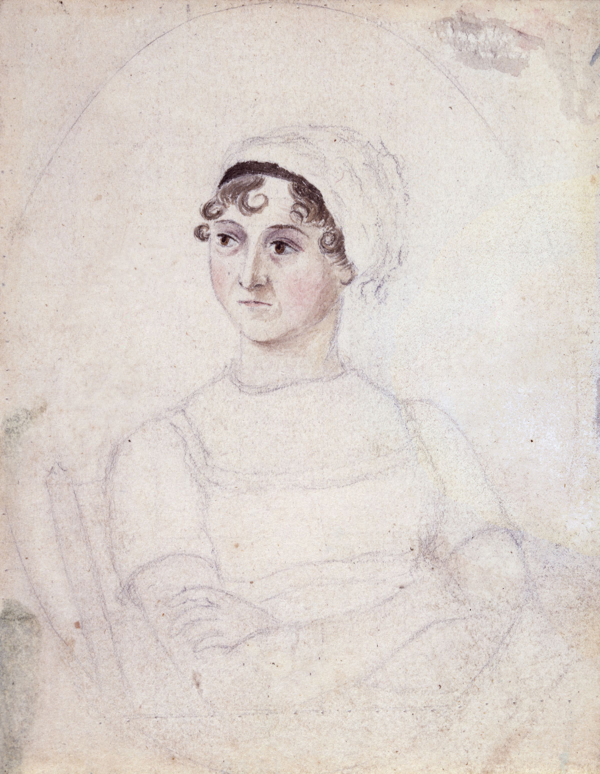

In [11]:
from PIL import Image

wikidata_pic_query = """
  SELECT ?author ?pic
    WHERE 
    {
      wd:Q36322 wdt:P18 ?pic .
      wd:Q36322 wdt:P735 ?author .

    }
"""

query_service_url = "https://query.wikidata.org/sparql"

params = {
    'format': 'json',
    'language': 'en',
    'query': wikidata_pic_query
    }

response = requests.get(query_service_url, params=params, headers=wiki_auth_headers)

data = response.json()
bindings = data["results"]["bindings"]
image_url = bindings[0]['pic']['value']

# request image as bytes data
img = Image.open(requests.get(image_url, stream=True, headers=wiki_auth_headers).raw)

# resize image to 25% of original
width, height = img.size
width = int(width * .25)
height = int(height * .25)

img = img.resize((width, height))
print(image_url)
display(img)

## Further reading + useful links

- Wikidata's documentation for accessing data [https://www.wikidata.org/wiki/Wikidata:Data_access](https://www.wikidata.org/wiki/Wikidata:Data_access)
- Wikidata's guide to their query service [https://www.wikidata.org/wiki/Wikidata:SPARQL_query_service/A_gentle_introduction_to_the_Wikidata_Query_Service](https://www.wikidata.org/wiki/Wikidata:SPARQL_query_service/A_gentle_introduction_to_the_Wikidata_Query_Service)
- GLAM Workbench Wikidata resources [https://glam-workbench.net/wikidata/](https://glam-workbench.net/wikidata/)
- Wikimedia's guide to Wikidata for cultural heritage [https://meta.wikimedia.org/wiki/A_Beginner%27s_Guide_to_Wikidata_for_Cultural_Heritage](https://meta.wikimedia.org/wiki/A_Beginner%27s_Guide_to_Wikidata_for_Cultural_Heritage)
- Video introduction to Wikidata from the National Library of Wales [https://www.youtube.com/watch?v=m_9_23jXPoE](https://www.youtube.com/watch?v=m_9_23jXPoE)